In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random as rnd
import time as t
import os 
import sys
import pandas as pd
print(f"imported at: {t.ctime()}")

import rdkit
from rdkit import Chem
from rdkit.Chem.Descriptors import ExactMolWt
from rdkit.Chem.Crippen import MolLogP
from rdkit.Chem.rdMolDescriptors import CalcTPSA

# rdkitdraw
from rdkit.Chem import Draw
import py3Dmol as dmol
from rdkit.Chem import AllChem

imported at: Wed Feb 18 21:02:30 2026


    train_loss  test_loss        lr
0     0.940715   0.641228  0.000100
1     0.519490   0.482687  0.000100
2     0.386011   0.399323  0.000100
3     0.315945   0.351527  0.000100
4     0.276722   0.324159  0.000100
5     0.251316   0.298588  0.000100
6     0.232777   0.293359  0.000100
7     0.218620   0.279752  0.000100
8     0.207480   0.264230  0.000100
9     0.198120   0.260209  0.000100
10    0.190144   0.250512  0.000100
11    0.183588   0.249949  0.000100
12    0.177494   0.247057  0.000100
13    0.172351   0.240705  0.000100
14    0.167669   0.245895  0.000100
15    0.163667   0.234810  0.000100
16    0.159731   0.234403  0.000100
17    0.156346   0.233872  0.000100
18    0.152882   0.236998  0.000100
19    0.149975   0.231982  0.000100
20    0.147183   0.231995  0.000100
21    0.144734   0.224778  0.000100
22    0.142166   0.224470  0.000100
23    0.140108   0.230478  0.000100
24    0.137896   0.224367  0.000100
25    0.135974   0.223493  0.000100
26    0.133949   0.223910  0

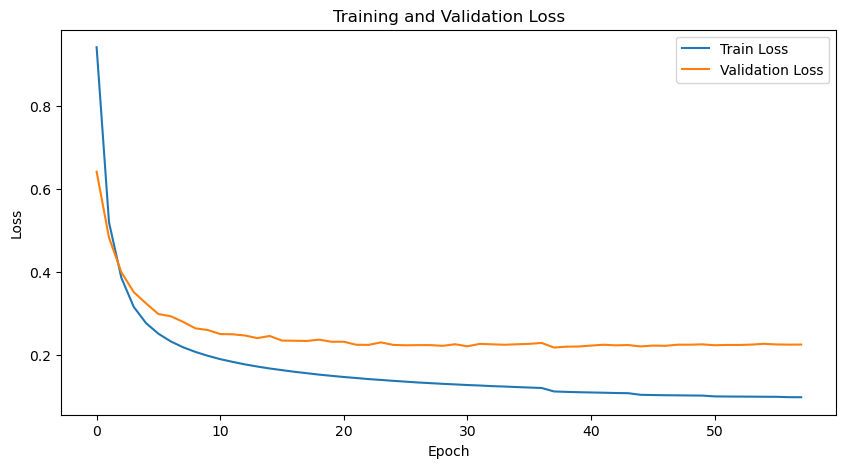

In [2]:
save_folder = "save/"
file = "history.csv"

df = pd.read_csv(save_folder + file)
print(df)

def plot_history(df:pd.DataFrame, save_folder:str, file:str):
    x = np.linspace(0, len(df)-1, len(df))
    plt.figure(figsize=(10, 5))
    plt.plot(x, df['train_loss'], label='Train Loss')
    plt.plot(x, df['test_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')


    plt.savefig(save_folder + "history_plot.png")
    plt.show()


plot_history(df, save_folder, file)

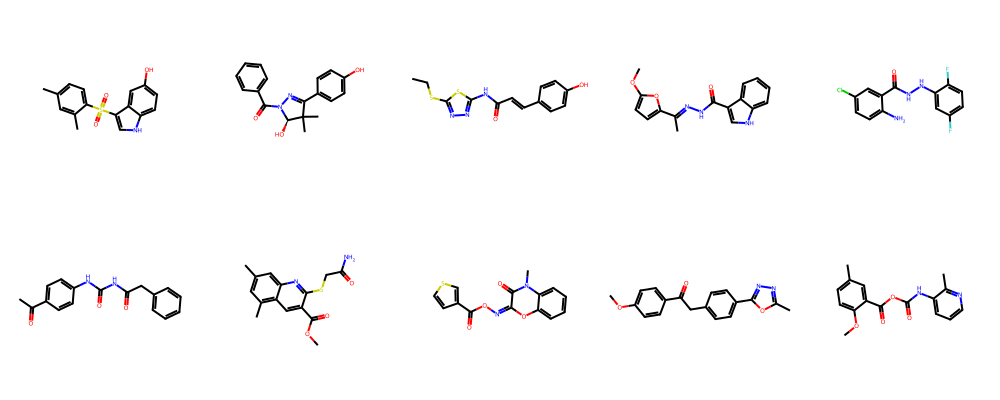

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

None

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

None

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

...

None

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

None

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

None

In [ ]:
# read molecules from file
# has columns: smiles, MW, LogP, TPSA
df = pd.read_csv("result.txt")



ms = [Chem.MolFromSmiles(s) for s in df['smiles']]
def avg_mv(mols):
    return sum([ExactMolWt(m) for m in mols])/len(mols)


samples = 10


def draw_samples(mols: list, samples: int) -> None:
    sample_mols = rnd.sample(mols, samples)
    img = Draw.MolsToGridImage(sample_mols, molsPerRow=5, subImgSize=(200, 200))
    display(img)



def draw_3d_samples(mols: list, samples: int) -> None:
    sample_mols = rnd.sample(mols, samples)
    for mol in sample_mols:
        # add hydrogens and embed the molecule in 3D space
        mol = Chem.AddHs(mol)
        AllChem.EmbedMolecule(mol)
        # optimize the molecule
        # for better visualization
        AllChem.MMFFOptimizeMolecule(mol)
        view = dmol.view(width=400, height=400)
        view.addModel(Chem.MolToMolBlock(mol), 'sdf')
        view.setStyle({'stick': {}})
        view.zoomTo()
        display(view.show())
    



draw_samples(ms, samples)

draw_3d_samples(ms, samples)

